# Rabi Oscillation Experiment Prototype v2
#### Using the Marki Microwave frequency mixer on both QCM-RM outputs, in order to view the pulse on the oscilloscope
#### v2 expands on v1 by allowing the sequence to be quickly looped, adjusting the RF pulse length and frequency as you go

Author: Kyle MacRobbie

---
---

## Expeiment sequence summary

|Step|Physical Description|Gate 1|Gate 2|QCM-RF output|
|-|-|-|-|-|
|1|Load electron into (1,0) state|Constant at -0.325 V|Constant at -0.25 V|None|
|2|Load electron into (2,0)S state|Constant at -0.395 V|Constant at -0.25 V|None|
|3|Tunnel electron into (1,1)S state|Ramp from -0.395 V to -0.325 V|Ramp from -0.25 V to -0.325 V|None|
|4|Apply RF pulse and do readout|Constant at -0.325 V|Constant at -0.325 V|RF pulse|
|5|Unload electrons|Ramp from -0.325 V to -0.38 V|Ramp from -0.325 V to -0.27 V|None|
|6|Unload electrons|Ramp from -0.38 V to -0.325 V|Ramp from -0.27 V to -0.25 V|None|

<br>

---
---

### Setup

In [86]:
# Imports
import time
import json
import matplotlib.pyplot as plt # type: ignore
import pyvisa # type: ignore
import numpy as np # type: ignore
import scipy # type: ignore
from numpy import random # type: ignore
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument # type: ignore
from qblox_instruments import Cluster, ClusterType # type: ignore
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module # type: ignore

In [2]:
# Run to get cluster IP
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'

# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')

# reset cluster and print cluster status
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


In [5]:
# Define which modules will be used
modules
qcm_module = modules[2]
qrm_module = modules[4]
rf_module = modules[6]

In [ ]:
# Check QCM
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qcm_module.is_qcm_type, qcm_module.is_qrm_type, qcm_module.is_rf_type))


QCM: True
QRM: False
RF: False


In [ ]:
# Check QCM-RF
print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))


QCM: True
QRM: False
RF: True


In [8]:
# Check QRM
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qrm_module.is_qcm_type, qrm_module.is_qrm_type, qrm_module.is_rf_type))


QCM: False
QRM: True
RF: False


### Connecting to oscilloscope

In [9]:
# Get a list of all connected devices
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL3::INSTR', 'GPIB0::8::INSTR')

In [10]:
# Connect to the oscillosocpe
scope = rm.open_resource('GPIB0::8::INSTR')
print(scope.query('*IDN?'))

*IDN LECROY,WP715ZI,LCRY0716N47852,8.5.0



### Global values that will remain constant through iterations

In [11]:
"""
With Qblox, when setting a voltage, you do not simply input the voltage you
would like to output.

For setting the offset, you use an integer between +/- 32768, which maps
linearly to outputs of +/- 1 V.
	For example, if you would like to output +0.5 V, your Q1ASM command
	would have to be:
		set_awg_offs	16384,16384
	since 16384 is 0.5 of 32768.

For playing waveforms, the values of the data points in that waveform can 
be in the range +/- 1, which corresponds to the fraction of the maximum
output of the module that will be outputted.
	For exampple, the QCM has a range of +/- 2.5 V, so playing a square
	waveform with amplitude 0.5 will output at a voltage of 0.5*2.5 V = 1.25 V.

Here we define these values as the voltages we wish to play, then account
for the input formats, which will then ultimately be used in the Q1ASM
sequence.
"""

qcm_range = 2.5				# +/- output voltage range of the QCM (5 V peak to peak)
awg_offs_range = 32768		# +/- range of Q1ASM arguements to the output offset on the QCM


offs11 = -0.325				# Offset for gate 1 step 1
offs12 = -0.395				# Offset for gate 1 step 2
offs11q1 = round((offs11/qcm_range)*awg_offs_range)     # Converting to account for Q1ASM arguement range
offs12q1 = round((offs12/qcm_range)*awg_offs_range)		# Converting to account for Q1ASM arguement range

ramp13_i = 0/qcm_range		# Start voltage for gate 1 step 3
ramp13_f = 0.07/qcm_range	# Final voltage for gate 1 step 3

offs14q1 = offs11q1			# Offset for gate 1 step 4

ramp15_i = 0/qcm_range		# Start voltage for gate 1 step 5
ramp15_f = -0.055/qcm_range # Final voltage for gate 1 step 5

ramp16_i = -0.055/qcm_range	# Start voltage for gate 1 step 6
ramp16_f = 0/qcm_range		# Final voltage for gate 1 step 6

offs21 = -0.25				# Offset for gate 2 step 1 
offs21q1 = round((offs21/qcm_range)*awg_offs_range)		# Converting to account for Q1ASM arguement range

ramp23_i = 0/qcm_range		# Start voltage for gate 2 step 3
ramp23_f = -0.075/qcm_range	# Final voltage for gate 2 step 3

offs24 = -0.325				# Offset for gate 2 step 4
offs24q1 = round((offs24/qcm_range)*awg_offs_range)		# Converting to account for Q1ASM arguement range

ramp25_i = 0/qcm_range		# Start voltage for gate 2 step 5
ramp25_f = 0.055/qcm_range	# Final voltage for gate 2 step 5

ramp26_i = 0.055/qcm_range	# Start voltage for gate 2 step 6
ramp26_f = 0.075/qcm_range	# Final voltage for gate 2 step 6

### End of setup

---
---

### Function to run the experiment for one iteration

In [96]:
def run_rabi_sequence(rf_pulse_length, rf_pulse_freq, gate_pulse_length):

	# MAKE WAVEFORMS

	waveforms_0 = {
		"ramp13" : {	# Ramp played on gate 1 in step 3
			"data": np.linspace(ramp13_i,ramp13_f,gate_pulse_length).tolist(),
			"index": 13
		},
		"ramp156": {	# Ramps played on gate 1 in steps 5 and 6
			"data": np.linspace(ramp15_i,ramp15_f,gate_pulse_length).tolist() + np.linspace(ramp16_i,ramp16_f,gate_pulse_length).tolist(),
			"index": 156
		},
	}
	waveforms_1 = {
		"ramp23" : {	# Ramp played on gate 2 in step 3
			"data": np.linspace(ramp23_i,ramp23_f,gate_pulse_length).tolist(),
			"index": 23
		},
		"ramp256": {	# Ramps played on gate 2 in steps 5 and 6
			"data": np.linspace(ramp25_i,ramp25_f,gate_pulse_length).tolist() + np.linspace(ramp26_i,ramp26_f,gate_pulse_length).tolist(),
			"index": 256
		},
	}
	waveforms_rf = {
		"block": {		# Block to be modulated and played as the RF pulse in step 4.
			"data": [1.0 for i in range(rf_pulse_length)],
			"index": 0
		}
	}

	# MAKE ACQUISITION
	acquisitions = {
		"acq": {"num_bins": 1, "index": 0}
	}


	# MAKE SEQUENCES

	# Syncing with other sequencers and resetting the offest to 0 if it is not already 0
	seq_qcm0 = f"""
		set_awg_offs	0,0
		upd_param		4
		wait_sync		4
	"""
	# Step 1: offset to -0.325 V for 5 µs
	seq_qcm0 += f"""
		set_awg_offs	{offs11q1},{offs11q1}
		upd_param		{gate_pulse_length}
	"""
	# Step 2: offset to -0.395 V for 5 µs
	seq_qcm0 += f"""
		set_awg_offs	{offs12q1},{offs12q1}
		upd_param		{gate_pulse_length}
	"""
	# Steps 3-4: ramping and RF pulse
	seq_qcm0 += f"""
		play			13,13,{gate_pulse_length}
		set_awg_offs	{offs14q1},{offs14q1}
		upd_param		{rf_pulse_length}
	"""
	# Steps 5-6: two ramps
	seq_qcm0 += f"""
		play			156,156,{gate_pulse_length*2}
	"""
	# Resetting offset to 0 and stopping
	seq_qcm0 += f"""
		set_awg_offs	0,0
		upd_param		4
		stop
	"""

	# Syncing with other sequencers and resetting the offest to 0 if it is not already 0
	seq_qcm1 = f"""
		set_awg_offs	0,0
		upd_param		4
		wait_sync		4
	"""
	# Step 1: offset to -0.325 V for 5 µs
	seq_qcm1 += f"""
		set_awg_offs	{offs21q1},{offs21q1}
		upd_param		{gate_pulse_length}
	"""
	# Step 2: offset to -0.395 V for 5 µs
	seq_qcm1 += f"""
		nop
		wait			{gate_pulse_length}
	"""
	# Steps 3-4: ramping and RF pulse
	seq_qcm1 += f"""
		play			23,23,{gate_pulse_length}
		set_awg_offs	{offs24q1},{offs24q1}
		upd_param		{rf_pulse_length}
	"""
	# Steps 5-6: two ramps
	seq_qcm1 += f"""
		play			256,256,{gate_pulse_length*2}
	"""
	# Resetting offset to 0 and stopping
	seq_qcm1 += f"""
		set_awg_offs	0,0
		upd_param		4
		stop
	"""

	# RF sequence, also sets marker for viewing on the oscilloscope
	seq_rf = f"""
		wait_sync	4
		set_mrk		{0b1111}
		upd_param	{gate_pulse_length*3}	# Wait until step 4

		play		0,0,{rf_pulse_length}

		wait 		{gate_pulse_length*2}
		
		set_mrk		{0b0000}
		upd_param	4
		nop
		stop
	"""

	# Reference 3 GHz so that we can use the frequency mixer and actually see the results on the oscilloscope
	seq_reference = f"""
		wait_sync	4
		wait		{gate_pulse_length*3}	# Wait until step 4

		play		0,0,{rf_pulse_length}

		stop
	"""

	# Readout sequence
	seq_readout = f"""
		wait_sync	4
		wait		{gate_pulse_length*3}	# Wait until step 4

		acquire		0,0,{rf_pulse_length}

		stop
	"""

	# UPLOAD SEQUENCES

	sequence_qcm0 = {
		"waveforms": waveforms_0,
		"weights": {},
		"acquisitions": {},
		"program": seq_qcm0,
	}
	sequence_qcm1 = {
		"waveforms": waveforms_1,
		"weights": {},
		"acquisitions": {},
		"program": seq_qcm1,
	}
	sequence_rf = {
		"waveforms": waveforms_rf,
		"weights": {},
		"acquisitions": {},
		"program": seq_rf,
	}
	sequence_reference = {
		"waveforms": waveforms_rf,
		"weights": {},
		"acquisitions": {},
		"program": seq_reference,
	}
	sequence_readout = {
		"waveforms": {},
		"weights": {},
		"acquisitions": acquisitions,
		"program": seq_readout,
	}

	qcm_module.sequencer0.sequence(sequence_qcm0)
	qcm_module.sequencer1.sequence(sequence_qcm1)
	rf_module.sequencer0.sequence(sequence_rf)
	rf_module.sequencer1.sequence(sequence_reference)
	qrm_module.sequencer0.sequence(sequence_readout)

	# CONFIGURE SEQUENCES AND START SEQUENCE

	# Disconnect previous output connections outputs
	qcm_module.disconnect_outputs()
	rf_module.disconnect_outputs()
	qrm_module.disconnect_outputs()
	qrm_module.disconnect_inputs()

	# Connect outputs and inputs
	qcm_module.sequencer0.connect_out0("I")
	qcm_module.sequencer1.connect_out1("I")
	rf_module.sequencer0.connect_out0(True)
	rf_module.sequencer1.connect_out1(True)
	qrm_module.sequencer0.connect_acq_I("in0") # Acquire through first input

	qrm_module.scope_acq_sequencer_select(0) # Configure scope mode
	qrm_module.scope_acq_trigger_mode_path0("sequencer")

	# Enable NCO and LO modulation and set their respective frequencies for output 0
	rf_module.sequencer0.mod_en_awg(True)
	rf_module.out0_lo_en(True)
	rf_module.sequencer0.nco_freq(100e6 + rf_pulse_freq)
	rf_module.out0_lo_freq(3e9)

	# Enable NCO and LO modulation and set their respective frequencies for output 1
	rf_module.sequencer1.mod_en_awg(True)
	rf_module.out1_lo_en(True)
	rf_module.sequencer1.nco_freq(100e6)
	rf_module.out1_lo_freq(3e9)

	qcm_module.sequencer0.sync_en(True)	# Enable sync
	qcm_module.sequencer1.sync_en(True)	# Enable sync
	rf_module.sequencer0.sync_en(True)	# Enable sync
	rf_module.sequencer1.sync_en(True)	# Enable sync
	qrm_module.sequencer0.sync_en(True)	# Enable sync

	qcm_module.arm_sequencer(0) # arm sequencer 0
	qcm_module.arm_sequencer(1) # arm sequencer 1
	rf_module.arm_sequencer(0)  # arm sequencer 0
	rf_module.arm_sequencer(1)  # arm sequencer 1
	qrm_module.arm_sequencer(0) # arm sequencer 0

	cluster.start_sequencer()	# Run the sequence

	qrm_module.get_acquisition_status(0) # Wait for the sequencer to stop with a timeout period of one minute.
	qrm_module.store_scope_acquisition(0, 'acq') # Move acquisition data from temporary memory to acquisition list.
	data = qrm_module.get_acquisitions(0) # Get acquisition list from instrument.

	print("QCM sequencer 0: " + str(qcm_module.get_sequencer_status(0)))
	print("QCM sequencer 1: " + str(qcm_module.get_sequencer_status(1)))
	print("QCM-RF sequencer 0: " + str(rf_module.get_sequencer_status(0)))
	print("QCM-RF sequencer 1: " + str(rf_module.get_sequencer_status(1)))
	print("QRM sequencer 0: " + str(rf_module.get_sequencer_status(0)))

	return data

### Reset and configure oscilloscope

In [97]:
scope.write(f'TIME_DIV {15e-6} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.12} V')	# Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {0.12} V')	# Set the voltage scale on channel 2
scope.write(f'C3:VOLT_DIV {0.5} V')		# Set the voltage scale on channel 3
scope.write(f'C4:VOLT_DIV {1.0} V')		# Set the voltage scale on channel 4
scope.write(f'TRIG_DELAY -15u')			# Set the time scale left/right on the display
scope.write(f'TRIG_MODE SINGLE')		# Set the trigger mode to "single" in order to take one acquisition

18

### Defining frequency, durations and looping through the pulse sequences

In [98]:
# Experiment variables
rf_pulse_length_ = 10000	# ns	# Length of the RF pulse (step 4)
rf_pulse_freq_ = 50e6		# Hz	# Frequency of the RF pulse (step 4)
gate_pulse_length_ = 5000	# ns	# Length of the gate pulses (all steps except 4). For now they are all set to the same length 

readout_data = run_rabi_sequence(rf_pulse_length_, rf_pulse_freq_, gate_pulse_length_)	# Run the sequence
print("\n")
time.sleep(35e-6)
readout_data = run_rabi_sequence(5000, 100e6, gate_pulse_length_)	# Run the sequence

QCM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


QCM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NO

In [87]:
qcm_module.stop_sequencer(0)
qrm_module.stop_sequencer(0)
rf_module.stop_sequencer(0)
qcm_module.stop_sequencer(1)
rf_module.stop_sequencer(1)

print("QCM sequencer 0: " + str(qcm_module.get_sequencer_status(0)))
print("QCM sequencer 1: " + str(qcm_module.get_sequencer_status(1)))
print("QCM-RF sequencer 0: " + str(rf_module.get_sequencer_status(0)))
print("QCM-RF sequencer 1: " + str(rf_module.get_sequencer_status(1)))
print("QRM sequencer 0: " + str(rf_module.get_sequencer_status(0)))

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

QCM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


1024


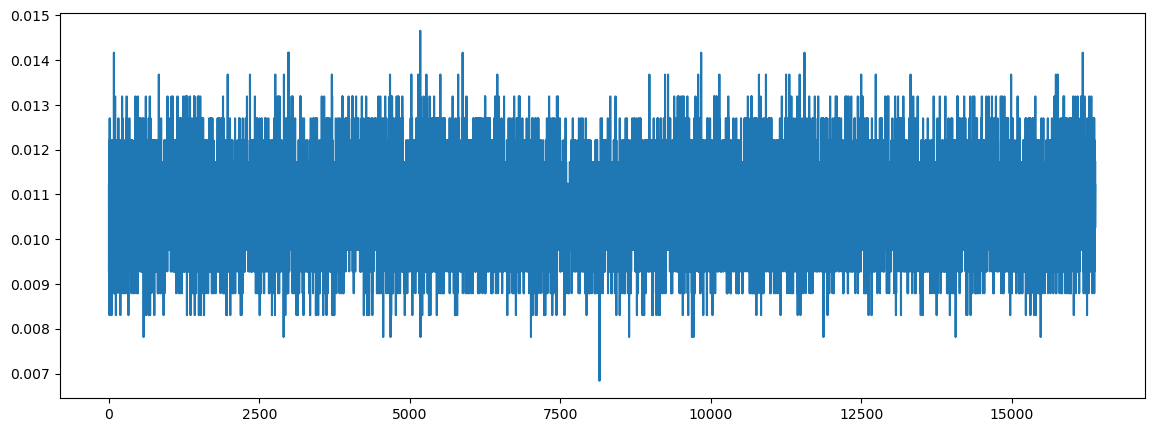

In [76]:
# Checking readout

readout = readout_data['acq']['acquisition']['scope']['path0']['data']

print(qrm_module.sequencer0.integration_length_acq())

#print("average = {}			integration average = {}".format((sum(readout)/len(readout)),readout_data['bins']['integration']['path0']/qrm_module.sequencer0.integration_length_acq()))

fig, ax = plt.subplots(1, 1, figsize = (14, 5))
ax.plot(readout)
plt.show()

In [73]:
readout_data

{'acq': {'index': 0,
  'acquisition': {'scope': {'path0': {'data': [0.009281875915974597,
      0.011235955056179775,
      0.010258915486077186,
      0.01074743527112848,
      0.009281875915974597,
      0.01074743527112848,
      0.01074743527112848,
      0.01172447484123107,
      0.009281875915974597,
      0.011235955056179775,
      0.008304836345872008,
      0.012212994626282364,
      0.01074743527112848,
      0.012701514411333659,
      0.009281875915974597,
      0.01172447484123107,
      0.010258915486077186,
      0.01074743527112848,
      0.010258915486077186,
      0.011235955056179775,
      0.009281875915974597,
      0.009281875915974597,
      0.009770395701025891,
      0.012212994626282364,
      0.009770395701025891,
      0.01074743527112848,
      0.008793356130923302,
      0.008793356130923302,
      0.010258915486077186,
      0.012212994626282364,
      0.01074743527112848,
      0.01172447484123107,
      0.010258915486077186,
      0.0117244748412310